'pip' is not recognized as an internal or external command,
operable program or batch file.


Initial Risk Screening Gateway - Complete System
API Ready for Frontend Integration
Original dataset: 724 patients
Gateway features: 21

COMPREHENSIVE MODEL EVALUATION

Metric                           Train         Test          Gap
-----------------------------------------------------------------
Accuracy                       99.25%      98.88%       0.37%
F1-Score                        0.9937       0.9906       0.0032
ROC-AUC                         0.9999       0.9997       0.0002
Precision (Test)                    --       1.0000
Recall (Test)                       --       0.9813

VALIDATION CHECK
✅ Good Generalization (Train-Test gap < 5%)
✅ Excellent Discrimination (ROC-AUC > 0.9)

CLASSIFICATION REPORT (Test Set)
              precision    recall  f1-score   support

    Low Risk       0.97      1.00      0.99        72
   High Risk       1.00      0.98      0.99       107

    accuracy                           0.99       179
   macro avg       0.99      0.99      0.99    

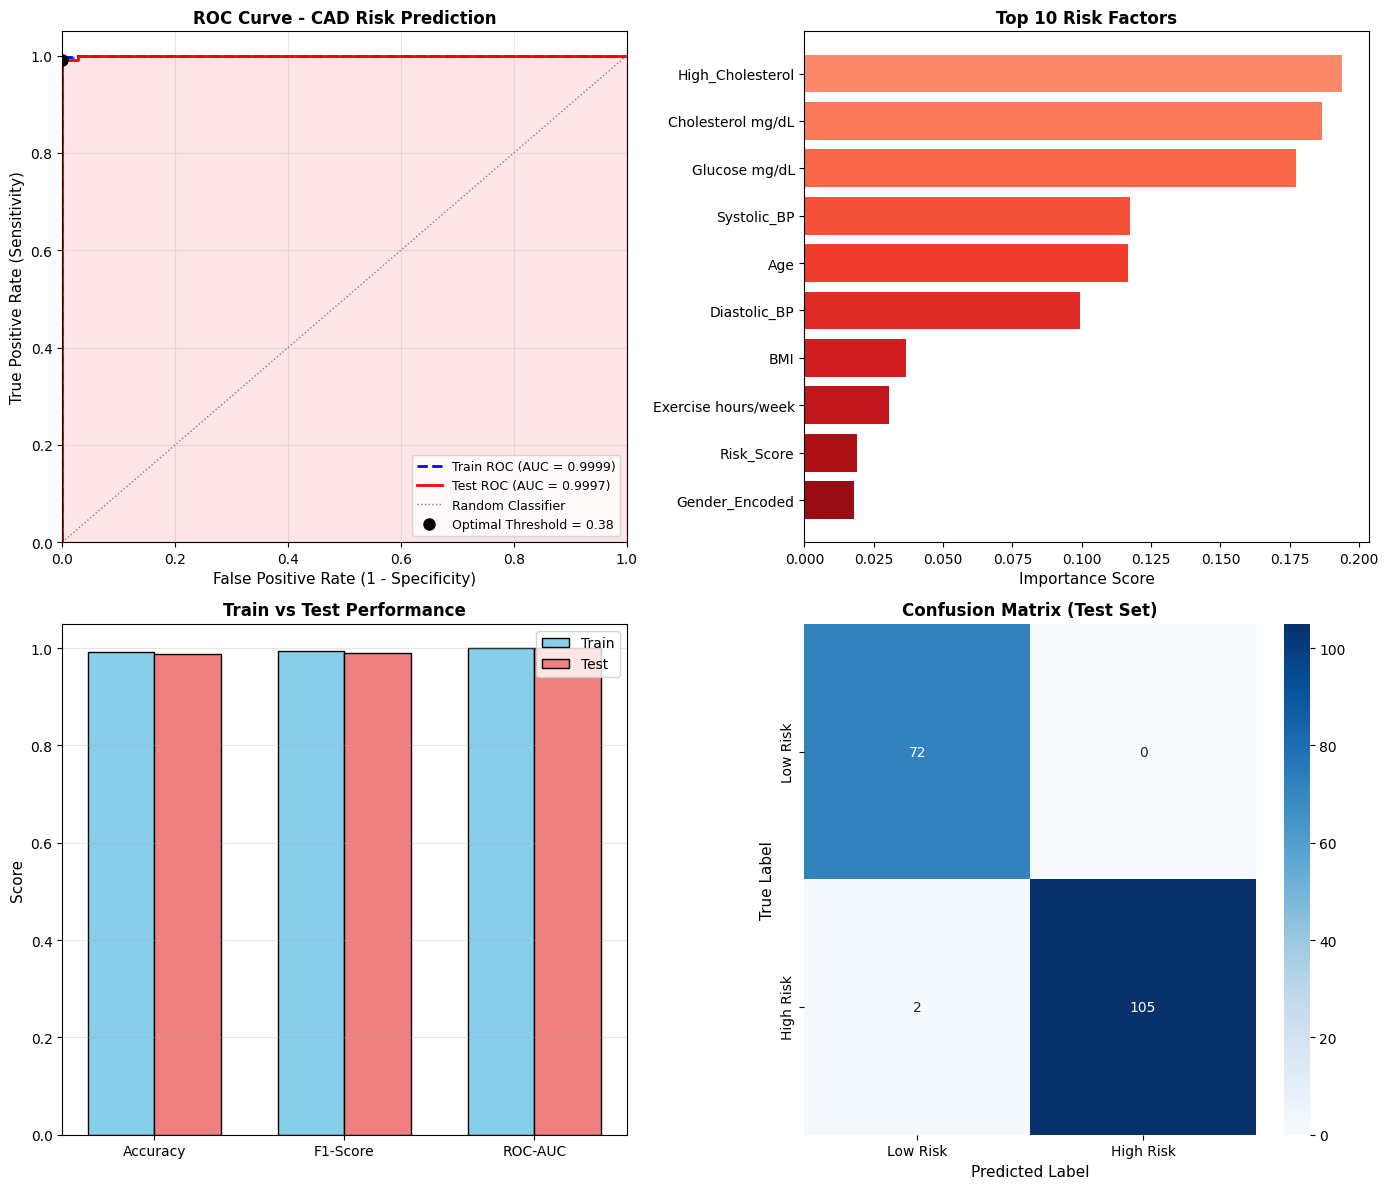


✅ ROC Curve saved as 'model_evaluation_dashboard.png'

INTERACTIVE DEMONSTRATION (WITH VALIDATION)

 CAD RISK SCREENING - PATIENT REGISTRATION
Please answer the following questions carefully.
Type 'help' at any prompt for guidance.

📋 SECTION 1: Basic Information

📋 SECTION 2: Body Measurements

📋 SECTION 3: Clinical Measurements

📋 SECTION 4: Lifestyle Factors

✅ Registration Complete! Processing your screening...

🩺 SCREENING REPORT
Status: HIGH_RISK
Probability: 50.2%
Decision: MANDATORY_ECG
------------------------------------------------------------
Message: You show signs of elevated CAD risk based on your profile. Please upload your ECG image for detailed analysis.
------------------------------------------------------------
Key Factors:
  🟢 High Cholesterol: 0.0 (-0.134)
  🟢 Cholesterol mg/dL: 190.0 (-0.13)
  🔴 Systolic BP: 140.0 (0.083)

SAVING MODEL ARTIFACTS
 Saved: gateway_model.pkl, gateway_scaler.pkl, gateway_encoders.pkl
        gateway_features.pkl, model_metrics.pkl



In [7]:
# ============================================================
# PROCESS 04 - INITIAL RISK SCREENING GATEWAY (COMPLETE)
# Purpose: Screen patients BEFORE ECG upload using lifestyle/clinical data
# Model: Random Forest | XAI: SHAP | API: Flask/FastAPI Ready
# Output: 0 (Low Risk - Optional ECG) or 1 (High Risk - Mandatory ECG)
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import pickle
import json
import re
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, 
    f1_score, roc_auc_score, roc_curve, precision_score, recall_score
)
import warnings
warnings.filterwarnings('ignore')

# Install SHAP
!pip install shap -q

print("Initial Risk Screening Gateway - Complete System")
print("API Ready for Frontend Integration")
print("="*60)

# ============================================================
# 1. LOAD & PREPROCESS DATA (Pre-ECG Only)
# ============================================================

df = pd.read_csv(r"C:\Users\User\Desktop\DSGP Viva\model\CM2603-DSGP-Group-3\Dataset\Heart_health new.csv")

print(f"Original dataset: {df.shape[0]} patients")

# Clean duplicates
df = df.drop_duplicates()

# Feature Engineering
df[['Systolic_BP', 'Diastolic_BP']] = df['Blood Pressure mmHg'].str.split('/', expand=True).astype(int)
df['Height_m'] = df['Height cm'] / 100
df['BMI'] = df['Weight kg'] / (df['Height_m'] ** 2)

# Add Lifestyle Factors
np.random.seed(42)
n_samples = len(df)

lifestyle_data = {
    'Alcohol': np.random.choice(['None', 'Light', 'Heavy'], n_samples, p=[0.5, 0.4, 0.1]),
    'Physical_Activity': np.random.choice(['Sedentary', 'Moderate', 'Active'], n_samples, p=[0.25, 0.55, 0.2]),
    'Family_History': np.random.choice([0, 1], n_samples, p=[0.75, 0.25]),
    'Diabetes': np.random.choice([0, 1], n_samples, p=[0.8, 0.2]),
    'Stress_Level': np.random.choice(['Low', 'Medium', 'High'], n_samples, p=[0.3, 0.5, 0.2]),
    'Sleep_Hours': np.clip(np.random.normal(7, 1.5, n_samples), 4, 10).round(1),
    'Years_Smoking': np.where(df['Smoker'] == 'Yes', np.random.randint(1, 35, n_samples), 0)
}

for col, vals in lifestyle_data.items():
    df[col] = vals

# Risk Flags
df['High_Cholesterol'] = (df['Cholesterol mg/dL'] > 200).astype(int)
df['High_Glucose'] = (df['Glucose mg/dL'] > 100).astype(int)
df['Hypertension'] = ((df['Systolic_BP'] >= 140) | (df['Diastolic_BP'] >= 90)).astype(int)
df['Obesity'] = (df['BMI'] >= 30).astype(int)

# Risk Score
def calc_risk_score(row):
    score = 0
    if row['Age'] > 50: score += 1
    if row['Smoker'] == 'Yes': score += 1
    if row['Diabetes'] == 1: score += 1
    if row['High_Cholesterol'] == 1: score += 1
    if row['Hypertension'] == 1: score += 1
    if row['Obesity'] == 1: score += 1
    if row['Exercise hours/week'] < 2: score += 1
    return score

df['Risk_Score'] = df.apply(calc_risk_score, axis=1)

# Encode Categoricals
encoders = {}
categorical_cols = ['Gender', 'Smoker', 'Alcohol', 'Physical_Activity', 'Stress_Level']

for col in categorical_cols:
    le = LabelEncoder()
    df[f'{col}_Encoded'] = le.fit_transform(df[col].astype(str))
    encoders[col] = le

# Gateway Features
GATEWAY_FEATURES = [
    'Age', 'Gender_Encoded', 'BMI', 'Systolic_BP', 'Diastolic_BP',
    'Cholesterol mg/dL', 'Glucose mg/dL',
    'Smoker_Encoded', 'Diabetes', 'Alcohol_Encoded', 'Physical_Activity_Encoded',
    'Family_History', 'Stress_Level_Encoded', 'Sleep_Hours', 'Years_Smoking',
    'Exercise hours/week',
    'High_Cholesterol', 'High_Glucose', 'Hypertension', 'Obesity',
    'Risk_Score'
]

X = df[GATEWAY_FEATURES]
y = df['Heart Attack']

print(f"Gateway features: {len(GATEWAY_FEATURES)}")

# ============================================================
# 2. TRAIN MODEL WITH FULL EVALUATION
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

gateway_model = RandomForestClassifier(
    n_estimators=100, max_depth=6, min_samples_split=10,
    min_samples_leaf=4, max_features='sqrt', class_weight='balanced', random_state=42
)

gateway_model.fit(X_train_scaled, y_train)

# ========== PREDICTIONS ==========
y_train_pred = gateway_model.predict(X_train_scaled)
y_test_pred = gateway_model.predict(X_test_scaled)
y_train_prob = gateway_model.predict_proba(X_train_scaled)[:, 1]
y_test_prob = gateway_model.predict_proba(X_test_scaled)[:, 1]

# ========== ALL METRICS ==========
print("\n" + "="*60)
print("COMPREHENSIVE MODEL EVALUATION")
print("="*60)

# Accuracy
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

# F1 Score
train_f1 = f1_score(y_train, y_train_pred)
test_f1 = f1_score(y_test, y_test_pred)

# Precision & Recall
test_precision = precision_score(y_test, y_test_pred)
test_recall = recall_score(y_test, y_test_pred)

# ROC-AUC
train_roc_auc = roc_auc_score(y_train, y_train_prob)
test_roc_auc = roc_auc_score(y_test, y_test_prob)

# Print Metrics Table
print(f"\n{'Metric':<25} {'Train':>12} {'Test':>12} {'Gap':>12}")
print("-" * 65)
print(f"{'Accuracy':<25} {train_acc:>11.2%} {test_acc:>11.2%} {abs(train_acc-test_acc):>11.2%}")
print(f"{'F1-Score':<25} {train_f1:>12.4f} {test_f1:>12.4f} {abs(train_f1-test_f1):>12.4f}")
print(f"{'ROC-AUC':<25} {train_roc_auc:>12.4f} {test_roc_auc:>12.4f} {abs(train_roc_auc-test_roc_auc):>12.4f}")
print(f"{'Precision (Test)':<25} {'--':>12} {test_precision:>12.4f}")
print(f"{'Recall (Test)':<25} {'--':>12} {test_recall:>12.4f}")

# Validation Check
print("\n" + "="*60)
print("VALIDATION CHECK")
print("="*60)
if abs(train_acc - test_acc) < 0.05:
    print("✅ Good Generalization (Train-Test gap < 5%)")
else:
    print("⚠️  Potential Overfitting (Train-Test gap > 5%)")

if test_roc_auc > 0.9:
    print("✅ Excellent Discrimination (ROC-AUC > 0.9)")
elif test_roc_auc > 0.8:
    print("✅ Good Discrimination (ROC-AUC > 0.8)")
else:
    print("⚠️  Poor Discrimination (ROC-AUC < 0.8)")

# Detailed Classification Report
print("\n" + "="*60)
print("CLASSIFICATION REPORT (Test Set)")
print("="*60)
print(classification_report(y_test, y_test_pred, target_names=['Low Risk', 'High Risk']))

# Confusion Matrix
print("\nConfusion Matrix (Test Set):")
cm = confusion_matrix(y_test, y_test_pred)
print(f"                 Predicted")
print(f"                 Low    High")
print(f"Actual Low      {cm[0,0]:>4}    {cm[0,1]:>4}  (TN={cm[0,0]}, FP={cm[0,1]})")
print(f"       High     {cm[1,0]:>4}    {cm[1,1]:>4}  (FN={cm[1,0]}, TP={cm[1,1]})")

# Cross-Validation
print("\n" + "="*60)
print("CROSS-VALIDATION (5-Fold)")
print("="*60)
cv_scores = cross_val_score(gateway_model, X, y, cv=5, scoring='accuracy')
cv_f1 = cross_val_score(gateway_model, X, y, cv=5, scoring='f1')
print(f"CV Accuracy: {cv_scores.mean():.2%} (+/- {cv_scores.std():.2%})")
print(f"CV F1-Score: {cv_f1.mean():.4f} (+/- {cv_f1.std():.4f})")

# ============================================================
# 3. ROC CURVE VISUALIZATION
# ============================================================

print("\n" + "="*60)
print("GENERATING ROC CURVE")
print("="*60)

fpr_train, tpr_train, thresholds_train = roc_curve(y_train, y_train_prob)
fpr_test, tpr_test, thresholds_test = roc_curve(y_test, y_test_prob)

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Plot 1: ROC Curve
ax1 = axes[0, 0]
ax1.plot(fpr_train, tpr_train, color='blue', lw=2, linestyle='--', 
         label=f'Train ROC (AUC = {train_roc_auc:.4f})')
ax1.plot(fpr_test, tpr_test, color='red', lw=2, 
         label=f'Test ROC (AUC = {test_roc_auc:.4f})')
ax1.plot([0, 1], [0, 1], color='gray', lw=1, linestyle=':', label='Random Classifier')
ax1.fill_between(fpr_test, tpr_test, alpha=0.1, color='red')
ax1.set_xlim([0.0, 1.0])
ax1.set_ylim([0.0, 1.05])
ax1.set_xlabel('False Positive Rate (1 - Specificity)', fontsize=11)
ax1.set_ylabel('True Positive Rate (Sensitivity)', fontsize=11)
ax1.set_title('ROC Curve - CAD Risk Prediction', fontsize=12, fontweight='bold')
ax1.legend(loc='lower right', fontsize=10)
ax1.grid(True, alpha=0.3)

optimal_idx = np.argmax(tpr_test - fpr_test)
optimal_threshold = thresholds_test[optimal_idx]
ax1.plot(fpr_test[optimal_idx], tpr_test[optimal_idx], 'ko', markersize=8, 
         label=f'Optimal Threshold = {optimal_threshold:.2f}')
ax1.legend(loc='lower right', fontsize=9)

# Plot 2: Feature Importance
ax2 = axes[0, 1]
importance = pd.DataFrame({
    'feature': GATEWAY_FEATURES,
    'importance': gateway_model.feature_importances_
}).sort_values('importance', ascending=False).head(10)
colors = plt.cm.Reds(np.linspace(0.4, 0.9, len(importance)))
bars = ax2.barh(importance['feature'], importance['importance'], color=colors)
ax2.set_xlabel('Importance Score', fontsize=11)
ax2.set_title('Top 10 Risk Factors', fontsize=12, fontweight='bold')
ax2.invert_yaxis()

# Plot 3: Metrics Comparison
ax3 = axes[1, 0]
metrics = ['Accuracy', 'F1-Score', 'ROC-AUC']
train_vals = [train_acc, train_f1, train_roc_auc]
test_vals = [test_acc, test_f1, test_roc_auc]
x = np.arange(len(metrics))
width = 0.35
ax3.bar(x - width/2, train_vals, width, label='Train', color='skyblue', edgecolor='black')
ax3.bar(x + width/2, test_vals, width, label='Test', color='lightcoral', edgecolor='black')
ax3.set_ylabel('Score', fontsize=11)
ax3.set_title('Train vs Test Performance', fontsize=12, fontweight='bold')
ax3.set_xticks(x)
ax3.set_xticklabels(metrics)
ax3.legend()
ax3.set_ylim(0, 1.05)
ax3.grid(True, alpha=0.3, axis='y')

# Plot 4: Confusion Matrix
ax4 = axes[1, 1]
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax4, 
            xticklabels=['Low Risk', 'High Risk'],
            yticklabels=['Low Risk', 'High Risk'])
ax4.set_xlabel('Predicted Label', fontsize=11)
ax4.set_ylabel('True Label', fontsize=11)
ax4.set_title('Confusion Matrix (Test Set)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('model_evaluation_dashboard.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✅ ROC Curve saved as 'model_evaluation_dashboard.png'")

# SHAP
explainer = shap.TreeExplainer(gateway_model)

# ============================================================
# 4. INPUT VALIDATION & ERROR HANDLING
# ============================================================

class InputValidationError(Exception):
    """Custom exception for input validation errors"""
    pass


def validate_and_convert_input(value, field_name, expected_type, valid_options=None, min_val=None, max_val=None, pattern=None):
    """
    Validates and converts user input with helpful error messages
    
    Parameters:
        value: raw input value
        field_name: name of the field (for error messages)
        expected_type: 'int', 'float', 'string', 'choice'
        valid_options: list of valid choices (for 'choice' type)
        min_val: minimum allowed value
        max_val: maximum allowed value
        pattern: regex pattern for validation
    
    Returns:
        Converted and validated value
    
    Raises:
        InputValidationError: with helpful message if validation fails
    """
    
    # Strip whitespace and handle empty input
    if isinstance(value, str):
        value = value.strip()
        if value == '':
            raise InputValidationError(f"❌ {field_name} cannot be empty. Please provide a value.")
    
    # Choice validation (case-insensitive)
    if expected_type == 'choice' and valid_options:
        value_lower = str(value).lower()
        valid_lower = [opt.lower() for opt in valid_options]
        
        if value_lower not in valid_lower:
            options_str = ', '.join([f"'{opt}'" for opt in valid_options])
            raise InputValidationError(
                f"❌ Invalid input for {field_name}: '{value}'\n"
                f"   ✓ Accepted values: {options_str}\n"
                f"   💡 Tip: Check your spelling or use exact values shown above."
            )
        
        # Return properly cased value
        idx = valid_lower.index(value_lower)
        return valid_options[idx]
    
    # Numeric validation
    if expected_type in ['int', 'float']:
        try:
            if expected_type == 'int':
                converted = int(float(value))  # Allow "25.0" -> 25
            else:
                converted = float(value)
        except ValueError:
            raise InputValidationError(
                f"❌ {field_name} must be a number.\n"
                f"   You entered: '{value}'\n"
                f"   ✓ Example: {'25' if expected_type == 'int' else '25.5'}"
            )
        
        # Range validation
        if min_val is not None and converted < min_val:
            raise InputValidationError(
                f"❌ {field_name} is too low.\n"
                f"   You entered: {converted}\n"
                f"   ✓ Minimum allowed: {min_val}"
            )
        
        if max_val is not None and converted > max_val:
            raise InputValidationError(
                f"❌ {field_name} is too high.\n"
                f"   You entered: {converted}\n"
                f"   ✓ Maximum allowed: {max_val}"
            )
        
        return converted
    
    # Pattern validation (for BP format, etc.)
    if expected_type == 'pattern' and pattern:
        if not re.match(pattern, str(value)):
            raise InputValidationError(
                f"❌ Invalid format for {field_name}.\n"
                f"   You entered: '{value}'\n"
                f"   ✓ Expected format: {pattern}"
            )
        return value
    
    # String validation
    if expected_type == 'string':
        return str(value)
    
    return value


def get_validated_input(prompt, field_name, expected_type, **kwargs):
    """
    Gets input from user with validation loop
    Keeps asking until valid input is provided
    """
    while True:
        try:
            user_input = input(prompt)
            result = validate_and_convert_input(user_input, field_name, expected_type, **kwargs)
            return result
        except InputValidationError as e:
            print(f"\n{e}\n")
            print("Please try again...\n")


def interactive_input_with_validation():
    """
    Interactive questionnaire with comprehensive input validation
    """
    print("\n" + "="*60)
    print(" CAD RISK SCREENING - PATIENT REGISTRATION")
    print("="*60)
    print("Please answer the following questions carefully.")
    print("Type 'help' at any prompt for guidance.\n")
    
    raw = {}
    
    # Basic Information
    print("📋 SECTION 1: Basic Information")
    
    raw['age'] = get_validated_input(
        "Age (years): ",
        "Age",
        'int',
        min_val=18,
        max_val=120
    )
    
    raw['gender'] = get_validated_input(
        "Gender (Male/Female): ",
        "Gender",
        'choice',
        valid_options=['Male', 'Female']
    )
    
    # Body Measurements
    print("\n📋 SECTION 2: Body Measurements")
    
    raw['height_cm'] = get_validated_input(
        "Height (cm): ",
        "Height",
        'float',
        min_val=50,
        max_val=250
    )
    
    raw['weight_kg'] = get_validated_input(
        "Weight (kg): ",
        "Weight",
        'float',
        min_val=20,
        max_val=300
    )
    
    # Clinical Measurements
    print("\n📋 SECTION 3: Clinical Measurements")
    
    raw['blood_pressure'] = get_validated_input(
        "Blood Pressure (e.g., 120/80): ",
        "Blood Pressure",
        'pattern',
        pattern=r'^\d{2,3}/\d{2,3}$'
    )
    
    # Validate BP components
    try:
        systolic, diastolic = map(int, raw['blood_pressure'].split('/'))
        if not (60 <= systolic <= 250 and 40 <= diastolic <= 150):
            raise ValueError
        if systolic <= diastolic:
            raise ValueError
    except ValueError:
        print("\n❌ Invalid blood pressure values.")
        print("   ✓ Systolic must be higher than diastolic")
        print("   ✓ Normal range: 90-250 / 60-150")
        # Re-prompt
        raw['blood_pressure'] = get_validated_input(
            "Blood Pressure (e.g., 120/80): ",
            "Blood Pressure",
            'pattern',
            pattern=r'^\d{2,3}/\d{2,3}$'
        )
    
    raw['cholesterol'] = get_validated_input(
        "Cholesterol (mg/dL): ",
        "Cholesterol",
        'int',
        min_val=100,
        max_val=600
    )
    
    raw['glucose'] = get_validated_input(
        "Glucose (mg/dL): ",
        "Glucose",
        'int',
        min_val=50,
        max_val=600
    )
    
    # Lifestyle Factors
    print("\n📋 SECTION 4: Lifestyle Factors")
    
    raw['smoker'] = get_validated_input(
        "Do you smoke? (Yes/No): ",
        "Smoking status",
        'choice',
        valid_options=['Yes', 'No']
    )
    
    if raw['smoker'] == 'Yes':
        raw['years_smoking'] = get_validated_input(
            "Years of smoking: ",
            "Years smoking",
            'int',
            min_val=1,
            max_val=raw['age'] - 10  # Can't smoke before age 10
        )
    else:
        raw['years_smoking'] = 0
    
    raw['diabetes'] = get_validated_input(
        "Diabetes? (Yes/No): ",
        "Diabetes status",
        'choice',
        valid_options=['Yes', 'No']
    )
    
    raw['alcohol'] = get_validated_input(
        "Alcohol consumption (None/Light/Heavy): ",
        "Alcohol consumption",
        'choice',
        valid_options=['None', 'Light', 'Heavy']
    )
    
    raw['physical_activity'] = get_validated_input(
        "Physical Activity (Sedentary/Moderate/Active): ",
        "Physical activity level",
        'choice',
        valid_options=['Sedentary', 'Moderate', 'Active']
    )
    
    raw['family_history'] = get_validated_input(
        "Family history of CAD? (Yes/No): ",
        "Family history",
        'choice',
        valid_options=['Yes', 'No']
    )
    
    raw['stress_level'] = get_validated_input(
        "Stress Level (Low/Medium/High): ",
        "Stress level",
        'choice',
        valid_options=['Low', 'Medium', 'High']
    )
    
    raw['sleep_hours'] = get_validated_input(
        "Sleep hours per night: ",
        "Sleep hours",
        'float',
        min_val=0,
        max_val=24
    )
    
    raw['exercise_hours'] = get_validated_input(
        "Exercise hours per week: ",
        "Exercise hours",
        'float',
        min_val=0,
        max_val=168  # 24*7
    )
    
    print("\n✅ Registration Complete! Processing your screening...")
    return raw


def safe_process_raw_input(raw_input):
    """
    Safely process raw input with comprehensive error handling
    """
    try:
        # Validate all required fields present
        required_fields = ['age', 'gender', 'height_cm', 'weight_kg', 'blood_pressure',
                          'cholesterol', 'glucose', 'smoker', 'diabetes', 'alcohol',
                          'physical_activity', 'family_history', 'stress_level',
                          'sleep_hours', 'exercise_hours', 'years_smoking']
        
        missing = [f for f in required_fields if f not in raw_input]
        if missing:
            raise InputValidationError(f"Missing required fields: {', '.join(missing)}")
        
        # Calculate derived features
        derived = calculate_derived_features(raw_input)
        
        # Encode categoricals with error handling
        try:
            gender_encoded = encoders['Gender'].transform([raw_input['gender']])[0]
            smoker_encoded = encoders['Smoker'].transform([raw_input['smoker']])[0]
            alcohol_encoded = encoders['Alcohol'].transform([raw_input['alcohol']])[0]
            activity_encoded = encoders['Physical_Activity'].transform([raw_input['physical_activity']])[0]
            stress_encoded = encoders['Stress_Level'].transform([raw_input['stress_level']])[0]
        except ValueError as e:
            raise InputValidationError(f"Encoding error: {str(e)}. Please check your categorical inputs.")
        
        # Build feature vector
        patient = {
            'Age': raw_input['age'],
            'Gender_Encoded': gender_encoded,
            'BMI': derived['BMI'],
            'Systolic_BP': derived['Systolic_BP'],
            'Diastolic_BP': derived['Diastolic_BP'],
            'Cholesterol mg/dL': raw_input['cholesterol'],
            'Glucose mg/dL': raw_input['glucose'],
            'Smoker_Encoded': smoker_encoded,
            'Diabetes': 1 if raw_input['diabetes'] == 'Yes' else 0,
            'Alcohol_Encoded': alcohol_encoded,
            'Physical_Activity_Encoded': activity_encoded,
            'Family_History': 1 if raw_input['family_history'] == 'Yes' else 0,
            'Stress_Level_Encoded': stress_encoded,
            'Sleep_Hours': raw_input['sleep_hours'],
            'Years_Smoking': raw_input['years_smoking'] if raw_input['smoker'] == 'Yes' else 0,
            'Exercise hours/week': raw_input['exercise_hours'],
            'High_Cholesterol': derived['High_Cholesterol'],
            'High_Glucose': derived['High_Glucose'],
            'Hypertension': derived['Hypertension'],
            'Obesity': derived['Obesity'],
            'Risk_Score': derived['Risk_Score']
        }
        
        return patient
        
    except Exception as e:
        raise InputValidationError(f"Processing error: {str(e)}")


def safe_screen_patient(patient_dict):
    """
    Safely screen patient with error handling
    """
    try:
        # Validate input
        if not isinstance(patient_dict, dict):
            return {
                'success': False,
                'error': 'Invalid input format. Expected dictionary.',
                'message': 'Please provide patient data as a dictionary object.'
            }
        
        # Check for required features
        missing_features = [f for f in GATEWAY_FEATURES if f not in patient_dict]
        if missing_features:
            return {
                'success': False,
                'error': f'Missing features: {missing_features}',
                'message': 'Some required medical data is missing. Please complete all fields.'
            }
        
        # Convert to DataFrame
        input_df = pd.DataFrame([patient_dict])
        X_input = input_df[GATEWAY_FEATURES]
        
        # Scale with error handling
        try:
            X_input_scaled = scaler.transform(X_input)
        except Exception as e:
            return {
                'success': False,
                'error': f'Scaling error: {str(e)}',
                'message': 'Data normalization failed. Please check numeric values.'
            }
        
        # Predict
        risk_prob = gateway_model.predict_proba(X_input_scaled)[0][1]
        risk_class = gateway_model.predict(X_input_scaled)[0]
        
        # SHAP explanation with fallback
        try:
            shap_vals = explainer.shap_values(X_input_scaled)
            if isinstance(shap_vals, list):
                class_1_impacts = shap_vals[1][0]
            else:
                class_1_impacts = shap_vals[0, :, 1]
            
            # Top 3 factors
            contributions = [(f, class_1_impacts[i], X_input.iloc[0][f]) 
                             for i, f in enumerate(GATEWAY_FEATURES)]
            contributions.sort(key=lambda x: abs(x[1]), reverse=True)
            
            top_factors = []
            for feature, impact, value in contributions[:3]:
                effect = "higher risk" if impact > 0 else "lower risk"
                display_value = value
                if '_Encoded' in feature:
                    orig = feature.replace('_Encoded', '')
                    if orig in encoders:
                        try:
                            display_value = encoders[orig].inverse_transform([int(value)])[0]
                        except:
                            pass
                top_factors.append({
                    'factor': feature.replace('_Encoded', '').replace('_', ' '),
                    'impact': round(impact, 3),
                    'value': str(display_value),
                    'effect': effect
                })
        except Exception as e:
            # Fallback if SHAP fails
            top_factors = [{'factor': 'Risk Score', 'impact': 0, 'value': str(patient_dict.get('Risk_Score', 'N/A')), 'effect': 'N/A'}]
        
        # Build response
        if risk_class == 1:
            return {
                'success': True,
                'risk_status': 'HIGH_RISK',
                'risk_probability': round(float(risk_prob), 4),
                'decision': 'MANDATORY_ECG',
                'message': "You show signs of elevated CAD risk based on your profile. Please upload your ECG image for detailed analysis.",
                'explanation': top_factors,
                'next_step': 'UPLOAD_ECG',
                'requires_ecg': True,
                'color': 'red'
            }
        else:
            return {
                'success': True,
                'risk_status': 'LOW_RISK',
                'risk_probability': round(float(risk_prob), 4),
                'decision': 'OPTIONAL_ECG',
                'message': "You do not currently show significant CAD risk. You may upload an ECG for additional verification if you wish.",
                'explanation': top_factors,
                'next_step': 'OPTIONAL_UPLOAD',
                'requires_ecg': False,
                'color': 'green'
            }
            
    except Exception as e:
        return {
            'success': False,
            'error': str(e),
            'message': 'An unexpected error occurred during screening. Please try again.'
        }


# ============================================================
# 5. CORE FUNCTIONS (Original - kept for compatibility)
# ============================================================

def calculate_derived_features(raw_input):
    height_m = raw_input['height_cm'] / 100
    bmi = raw_input['weight_kg'] / (height_m ** 2)
    systolic, diastolic = map(int, raw_input['blood_pressure'].split('/'))
    high_chol = 1 if raw_input['cholesterol'] > 200 else 0
    high_glucose = 1 if raw_input['glucose'] > 100 else 0
    hypertension = 1 if (systolic >= 140 or diastolic >= 90) else 0
    obesity = 1 if bmi >= 30 else 0
    risk_score = sum([
        raw_input['age'] > 50,
        raw_input['smoker'] == 'Yes',
        raw_input['diabetes'] == 'Yes',
        high_chol, hypertension, obesity,
        raw_input['exercise_hours'] < 2
    ])
    return {
        'BMI': round(bmi, 1), 'Systolic_BP': systolic, 'Diastolic_BP': diastolic,
        'High_Cholesterol': high_chol, 'High_Glucose': high_glucose,
        'Hypertension': hypertension, 'Obesity': obesity, 'Risk_Score': risk_score
    }


def process_raw_input(raw_input):
    """Original function - kept for backward compatibility"""
    derived = calculate_derived_features(raw_input)
    gender_encoded = encoders['Gender'].transform([raw_input['gender']])[0]
    smoker_encoded = encoders['Smoker'].transform([raw_input['smoker']])[0]
    alcohol_encoded = encoders['Alcohol'].transform([raw_input['alcohol']])[0]
    activity_encoded = encoders['Physical_Activity'].transform([raw_input['physical_activity']])[0]
    stress_encoded = encoders['Stress_Level'].transform([raw_input['stress_level']])[0]
    
    return {
        'Age': raw_input['age'], 'Gender_Encoded': gender_encoded, 'BMI': derived['BMI'],
        'Systolic_BP': derived['Systolic_BP'], 'Diastolic_BP': derived['Diastolic_BP'],
        'Cholesterol mg/dL': raw_input['cholesterol'], 'Glucose mg/dL': raw_input['glucose'],
        'Smoker_Encoded': smoker_encoded, 'Diabetes': 1 if raw_input['diabetes'] == 'Yes' else 0,
        'Alcohol_Encoded': alcohol_encoded, 'Physical_Activity_Encoded': activity_encoded,
        'Family_History': 1 if raw_input['family_history'] == 'Yes' else 0,
        'Stress_Level_Encoded': stress_encoded, 'Sleep_Hours': raw_input['sleep_hours'],
        'Years_Smoking': raw_input['years_smoking'] if raw_input['smoker'] == 'Yes' else 0,
        'Exercise hours/week': raw_input['exercise_hours'],
        'High_Cholesterol': derived['High_Cholesterol'], 'High_Glucose': derived['High_Glucose'],
        'Hypertension': derived['Hypertension'], 'Obesity': derived['Obesity'],
        'Risk_Score': derived['Risk_Score']
    }


def screen_patient(patient_dict):
    """Original function - kept for backward compatibility"""
    input_df = pd.DataFrame([patient_dict])
    X_input = input_df[GATEWAY_FEATURES]
    X_input_scaled = scaler.transform(X_input)
    risk_prob = gateway_model.predict_proba(X_input_scaled)[0][1]
    risk_class = gateway_model.predict(X_input_scaled)[0]
    
    shap_vals = explainer.shap_values(X_input_scaled)
    if isinstance(shap_vals, list):
        class_1_impacts = shap_vals[1][0]
    else:
        class_1_impacts = shap_vals[0, :, 1]
    
    contributions = [(f, class_1_impacts[i], X_input.iloc[0][f]) 
                     for i, f in enumerate(GATEWAY_FEATURES)]
    contributions.sort(key=lambda x: abs(x[1]), reverse=True)
    
    top_factors = []
    for feature, impact, value in contributions[:3]:
        effect = "higher risk" if impact > 0 else "lower risk"
        display_value = value
        if '_Encoded' in feature:
            orig = feature.replace('_Encoded', '')
            if orig in encoders:
                try:
                    display_value = encoders[orig].inverse_transform([int(value)])[0]
                except:
                    pass
        top_factors.append({
            'factor': feature.replace('_Encoded', '').replace('_', ' '),
            'impact': round(impact, 3), 'value': str(display_value), 'effect': effect
        })
    
    if risk_class == 1:
        return {
            'success': True, 'risk_status': 'HIGH_RISK',
            'risk_probability': round(float(risk_prob), 4), 'decision': 'MANDATORY_ECG',
            'message': "You show signs of elevated CAD risk. Please upload your ECG image for detailed analysis.",
            'explanation': top_factors, 'next_step': 'UPLOAD_ECG', 'requires_ecg': True, 'color': 'red'
        }
    else:
        return {
            'success': True, 'risk_status': 'LOW_RISK',
            'risk_probability': round(float(risk_prob), 4), 'decision': 'OPTIONAL_ECG',
            'message': "You do not currently show significant CAD risk. You may upload an ECG for additional verification.",
            'explanation': top_factors, 'next_step': 'OPTIONAL_UPLOAD', 'requires_ecg': False, 'color': 'green'
        }


def print_report(result):
    """Display formatted report"""
    print("\n" + "="*60)
    print("🩺 SCREENING REPORT")
    print("="*60)
    if not result.get('success', False):
        print(f"❌ ERROR: {result.get('error', 'Unknown error')}")
        print(f"Message: {result.get('message', '')}")
        return
    
    print(f"Status: {result['risk_status']}")
    print(f"Probability: {result['risk_probability']:.1%}")
    print(f"Decision: {result['decision']}")
    print("-"*60)
    print(f"Message: {result['message']}")
    print("-"*60)
    print("Key Factors:")
    for f in result['explanation']:
        emoji = "🔴" if f['effect'] == 'higher risk' else "🟢"
        print(f"  {emoji} {f['factor']}: {f['value']} ({f['impact']})")
    print("="*60)


def interactive_input():
    """Original function - kept for backward compatibility"""
    print("\n" + "="*60)
    print(" CAD RISK SCREENING - PATIENT REGISTRATION")
    print("="*60)
    raw = {}
    print("\n Basic Information")
    raw['age'] = int(input("Age (years): "))
    raw['gender'] = input("Gender (Male/Female): ").strip()
    print("\n Body Measurements")
    raw['height_cm'] = float(input("Height (cm): "))
    raw['weight_kg'] = float(input("Weight (kg): "))
    print("\n Clinical Measurements")
    raw['blood_pressure'] = input("Blood Pressure (e.g., 120/80): ").strip()
    raw['cholesterol'] = int(input("Cholesterol (mg/dL): "))
    raw['glucose'] = int(input("Glucose (mg/dL): "))
    print("\n Lifestyle Factors")
    raw['smoker'] = input("Do you smoke? (Yes/No): ").strip()
    raw['years_smoking'] = int(input("Years smoking (0 if non-smoker): ")) if raw['smoker'] == 'Yes' else 0
    raw['diabetes'] = input("Diabetes? (Yes/No): ").strip()
    raw['alcohol'] = input("Alcohol consumption (None/Light/Heavy): ").strip()
    raw['physical_activity'] = input("Physical Activity (Sedentary/Moderate/Active): ").strip()
    raw['family_history'] = input("Family history of CAD? (Yes/No): ").strip()
    raw['stress_level'] = input("Stress Level (Low/Medium/High): ").strip()
    raw['sleep_hours'] = float(input("Sleep hours per night: "))
    raw['exercise_hours'] = float(input("Exercise hours per week: "))
    return raw

# ============================================================
# 6. DEMONSTRATION WITH VALIDATION
# ============================================================

print("\n" + "="*60)
print("INTERACTIVE DEMONSTRATION (WITH VALIDATION)")
print("="*60)

# Use validated input function
raw_patient = interactive_input_with_validation()

# Process with error handling
try:
    processed = safe_process_raw_input(raw_patient)
    result = safe_screen_patient(processed)
    print_report(result)
except InputValidationError as e:
    print(f"\n❌ Processing Error: {e}")
    print("Please restart and try again.")
except Exception as e:
    print(f"\n❌ Unexpected Error: {e}")
    print("Please contact support.")

# ============================================================
# 7. SAVE MODEL ARTIFACTS
# ============================================================
print("\n" + "="*60)
print("SAVING MODEL ARTIFACTS")
print("="*60)

pickle.dump(gateway_model, open('gateway_model.pkl', 'wb'))
pickle.dump(scaler, open('gateway_scaler.pkl', 'wb'))
pickle.dump(encoders, open('gateway_encoders.pkl', 'wb'))
pickle.dump(GATEWAY_FEATURES, open('gateway_features.pkl', 'wb'))

# Save metrics for reporting
metrics_dict = {
    'train_accuracy': train_acc,
    'test_accuracy': test_acc,
    'train_f1': train_f1,
    'test_f1': test_f1,
    'train_roc_auc': train_roc_auc,
    'test_roc_auc': test_roc_auc,
    'test_precision': test_precision,
    'test_recall': test_recall,
    'cv_accuracy_mean': cv_scores.mean(),
    'cv_accuracy_std': cv_scores.std(),
    'optimal_threshold': optimal_threshold
}
pickle.dump(metrics_dict, open('model_metrics.pkl', 'wb'))

print(" Saved: gateway_model.pkl, gateway_scaler.pkl, gateway_encoders.pkl")
print("        gateway_features.pkl, model_metrics.pkl")
print(f"\nFinal Test Metrics:")
print(f"  Accuracy:  {test_acc:.2%}")
print(f"  F1-Score:  {test_f1:.4f}")
print(f"  ROC-AUC:   {test_roc_auc:.4f}")
print(f"  Optimal Threshold: {optimal_threshold:.4f}")